# Tarang ECG Classifier v5 — Two-Model Architecture + Digital Twin

**Team Ocelleon — IoT Challenge 2026**

## What changed from v4 → v5

| Item | v4 | v5 |
|------|----|----|
| Sample rate | 360 Hz (wrong) | **250 Hz** (matches EFR32MG26 IADC) |
| Window | 187 samples / 519 ms | **130 samples / 520 ms** (65 pre + 65 post) |
| Architecture | Single 3-class model (N/S/V) | **Two-model cascade: Gate (N/Abnormal) → SV discriminator (S/V)** |
| RR features | 5 features | **7 features** (+compensatory_ratio, +prematurity_index) |
| SVDB channel | All duplicated ch0 → bug | **SVDB single-lead excluded from Gate; used only for SV discriminator S-class** |
| rr_next leakage | Untested | **Robustness test: zero-out rr_next, measure degradation** |
| Digital twin | None | **Full end-to-end pipeline simulation: raw signal → NLMS → Pan-Tompkins → Gate → SV → BLE packet** |

## Two-Model Flow (firmware-accurate)
```
250 Hz ECG (LDMA, zero-CPU)
   └─► Pan-Tompkins R-peak detected
          └─► IMU motion gate: is_in_motion? → SKIP (motion artifact)
                 └─► Extract 130-sample window (65 pre / 65 post)
                        └─► MODEL 1: Gate CNN (N vs Abnormal)  ~5-10 KB
                               result=N → done, no further inference
                               result=Abnormal
                                  └─► MODEL 2: SV discriminator (S vs V)  ~25 KB
                                         result → BLE anomaly packet
```
Total flash: ~30-35 KB INT8. Both models share the same trigger — neither runs continuously.


In [1]:
import os, json, subprocess, warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample_poly

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_curve, auc)

warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

# ── PATHS — edit these ────────────────────────────────────────────────────────
MITBIH_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0'
SVDB_PATH   = 'C:\MMD Public\Hackathons\Team Ocelleon\dataset\mit-bih-supraventricular-arrhythmia-database-1.0.0'

OUTPUTS_DIR          = 'outputs_v5'
GATE_CHECKPOINT      = f'{OUTPUTS_DIR}/tarang_gate_best.keras'
SV_CHECKPOINT        = f'{OUTPUTS_DIR}/tarang_sv_best.keras'
GATE_TFLITE_PATH     = f'{OUTPUTS_DIR}/tarang_gate_int8.tflite'
SV_TFLITE_PATH       = f'{OUTPUTS_DIR}/tarang_sv_int8.tflite'
GATE_HEADER_PATH     = f'{OUTPUTS_DIR}/tarang_gate_model.h'
SV_HEADER_PATH       = f'{OUTPUTS_DIR}/tarang_sv_model.h'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── WINDOW — 250 Hz, firmware-accurate ───────────────────────────────────────
# 65 pre + 65 post = 130 samples = 520 ms at 250 Hz
# (vs v4: 93+94=187 samples at 360 Hz = 519 ms — same physical window, correct FS)
# DO NOT CHANGE without updating firmware LDMA buffer and Pan-Tompkins window
FS          = 250        # EFR32MG26 IADC — confirmed in app.c
WINDOW_PRE  = 65
WINDOW_POST = 65
WINDOW_LEN  = WINDOW_PRE + WINDOW_POST   # 130 samples

# MIT-BIH and SVDB are recorded at 360 Hz — resample to 250 Hz
FS_ORIG = 360

CONFIDENCE_THRESHOLD_GATE = 0.60   # Gate: lower threshold → catch all abnormal
CONFIDENCE_THRESHOLD_SV   = 0.50   # SV: balanced S/V

print(f"TensorFlow : {tf.__version__}")
print(f"WFDB       : {wfdb.__version__}")
print(f"Target FS  : {FS} Hz  (resample from {FS_ORIG} Hz)")
print(f"Window     : {WINDOW_LEN} samples = {WINDOW_LEN/FS*1000:.1f} ms")
print(f"MIT-BIH    : {MITBIH_PATH}")
print(f"SVDB       : {SVDB_PATH}  (exists={os.path.isdir(SVDB_PATH)})")
print(f"Outputs    : {OUTPUTS_DIR}/")


GPU memory growth enabled for 1 GPU(s)
TensorFlow : 2.10.1
WFDB       : 4.1.2
Target FS  : 250 Hz  (resample from 360 Hz)
Window     : 130 samples = 520.0 ms
MIT-BIH    : C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0
SVDB       : C:\MMD Public\Hackathons\Team Ocelleon\dataset\mit-bih-supraventricular-arrhythmia-database-1.0.0  (exists=True)
Outputs    : outputs_v5/


In [2]:
# AAMI/ANSI EC57 — clinical standard
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'V',   # Fusion → V (conservative; note: inflates V training slightly)
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'V', 'S']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

# Patient-wise split — no data leakage
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS
                        and r not in MITBIH_VAL_RECORDS]

SVDB_RECORDS = [f'{i}' for i in range(800, 895)]

print(f"MIT-BIH train : {len(MITBIH_TRAIN_RECORDS)} records")
print(f"MIT-BIH val   : {len(MITBIH_VAL_RECORDS)} records")
print(f"MIT-BIH test  : {len(MITBIH_TEST_RECORDS)} records (held out)")
print(f"SVDB          : {len(SVDB_RECORDS)} records (S-class boost for SV discriminator only)")
print()
print("Two-model data strategy:")
print("  GATE model  — MIT-BIH only (N vs Abnormal). SVDB excluded: single-lead domain gap")
print("                would corrupt the Gate's Normal baseline.")
print("  SV model    — MIT-BIH S+V + SVDB S (adds S diversity, acceptable single-lead since")
print("                Gate has already filtered to Abnormal beats — morphology focus only)")


MIT-BIH train : 18 records
MIT-BIH val   : 4 records
MIT-BIH test  : 26 records (held out)
SVDB          : 95 records (S-class boost for SV discriminator only)

Two-model data strategy:
  GATE model  — MIT-BIH only (N vs Abnormal). SVDB excluded: single-lead domain gap
                would corrupt the Gate's Normal baseline.
  SV model    — MIT-BIH S+V + SVDB S (adds S diversity, acceptable single-lead since
                Gate has already filtered to Abnormal beats — morphology focus only)


In [3]:
def rolling_window_normalize(signal, window_samples=7500):
    """
    Simulates firmware 30s Welford rolling normalization at 250 Hz.
    window_samples = 7500 = 30s × 250 Hz
    (v4 used 10800 = 30s × 360 Hz — now corrected)
    """
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks, beat_idx):
    """
    7 RR-interval features for one beat (expanded from v4's 5).

    peaks    : full sorted R-peak sample array (in 250 Hz sample indices)
    beat_idx : index of current beat in peaks[]

    Returns float32 (7,):
      [rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
       compensatory_ratio, prematurity_index]

    New features:
      compensatory_ratio = rr_next / rr_prev
        PVC:  rr_next >> rr_prev (full compensatory pause, ratio > 1.8)
        SVE:  rr_next < 1.5 × rr_prev (incomplete pause, ratio < 1.5)
        → Strongest single S-vs-V discriminator in rhythm domain

      prematurity_index = rr_prev / rr_mean_5
        < 0.85 strongly indicates ectopic beat (premature)
        Used in both Gate and SV discriminator

    Firmware replicates this from the Pan-Tompkins RR ring buffer.
    rr_next = 0.0 is safe — firmware uses this before next peak arrives.
    """
    n = len(peaks)
    i = beat_idx

    prev_idx = max(0, i-1)
    next_idx = min(n-1, i+1)
    rr_prev  = (peaks[i]      - peaks[prev_idx]) / FS
    rr_next  = (peaks[next_idx] - peaks[i])      / FS
    rr_ratio = rr_prev / max(rr_next, 1e-4)

    lo = max(0, i-2); hi = min(n-1, i+2)
    local_rrs = np.diff(peaks[lo:hi+1]).astype(np.float32) / FS
    rr_mean_5 = float(np.mean(local_rrs)) if len(local_rrs) > 0 else rr_prev
    rr_std_5  = float(np.std(local_rrs))  if len(local_rrs) > 0 else 0.0

    compensatory_ratio = rr_next / max(rr_prev, 1e-4)   # >1.8 → V, <1.5 → S
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)  # <0.85 → ectopic

    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                     compensatory_ratio, prematurity_index], dtype=np.float32)

RR_FEATURE_NAMES = ['rr_prev','rr_next','rr_ratio','rr_mean_5','rr_std_5',
                     'compensatory_ratio','prematurity_index']

print(f"RR feature vector: {len(RR_FEATURE_NAMES)} features")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name}")
print()
print("Key new features:")
print("  compensatory_ratio: PVC>1.8, SVE<1.5 — strongest S/V rhythm discriminator")
print("  prematurity_index : <0.85 → ectopic — helps Gate identify any abnormal beat")


RR feature vector: 7 features
  [0] rr_prev
  [1] rr_next
  [2] rr_ratio
  [3] rr_mean_5
  [4] rr_std_5
  [5] compensatory_ratio
  [6] prematurity_index

Key new features:
  compensatory_ratio: PVC>1.8, SVE<1.5 — strongest S/V rhythm discriminator
  prematurity_index : <0.85 → ectopic — helps Gate identify any abnormal beat


In [4]:
def load_records(db_path, record_list, source_tag, two_channel=True,
                 classes_filter=None):
    """
    Load and resample beats from MIT-BIH or SVDB to 250 Hz.

    Resampling:
      scipy.signal.resample_poly(signal, up=25, down=36)
      250/360 = 25/36 exactly — anti-aliased polyphase filter.
      Peak indices rescaled: peak_250 = round(peak_360 * 250/360)
      (Never re-run peak detection on resampled signal — use cardiologist annotations)

    classes_filter: if set, only return beats of these classes (e.g. ['S','V'])
    """
    if classes_filter is None:
        classes_filter = CLASSES_TO_USE

    all_beats, all_rr, all_labels, all_recs = [], [], [], []
    channel_log = {}

    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')

            n_ch = record.p_signal.shape[1]
            channel_log[rec_str] = n_ch

            # ── Resample 360→250 Hz with anti-aliasing ──────────────────────
            sig_ch0_360 = record.p_signal[:, 0]
            sig_ch0_250 = resample_poly(sig_ch0_360, up=25, down=36).astype(np.float32)

            if two_channel and n_ch > 1:
                sig_ch1_250 = resample_poly(record.p_signal[:, 1],
                                            up=25, down=36).astype(np.float32)
                is_duplicated = False
            else:
                sig_ch1_250   = sig_ch0_250.copy()
                is_duplicated = True

            # ── Rescale peak indices (do NOT re-detect peaks) ────────────────
            peaks_360 = annotation.sample
            peaks_250 = np.round(peaks_360 * (250.0 / 360.0)).astype(int)
            syms      = annotation.symbol

            sig_len_250 = len(sig_ch0_250)

            # ── Normalize (30s rolling, 250 Hz window) ───────────────────────
            ecg_ch0 = rolling_window_normalize(sig_ch0_250)
            ecg_ch1 = rolling_window_normalize(sig_ch1_250)

            valid_idxs = [i for i, s in enumerate(syms)
                          if BEAT_MAP.get(s, None) in classes_filter]

            beats_this = 0
            for idx in valid_idxs:
                peak   = peaks_250[idx]
                mapped = BEAT_MAP[syms[idx]]

                if (peak - WINDOW_PRE < 0 or
                        peak + WINDOW_POST >= sig_len_250):
                    continue

                beat = np.stack([
                    ecg_ch0[peak - WINDOW_PRE : peak + WINDOW_POST],
                    ecg_ch1[peak - WINDOW_PRE : peak + WINDOW_POST],
                ], axis=-1).astype(np.float32)   # (130, 2)

                if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                    continue

                rr = compute_rr_features(peaks_250, idx)

                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(mapped)
                all_recs.append(f'{source_tag}_{rec_str}')
                beats_this += 1

            dup_tag = ' [CH1=DUP]' if is_duplicated else ''
            print(f"  {source_tag}/{rec_str}: {beats_this} beats  ({n_ch}ch{dup_tag})")

        except Exception as ex:
            print(f"  {source_tag}/{rec_str}: FAILED — {ex}")

    n_dup = sum(1 for v in channel_log.values() if v == 1)
    print(f"  Summary: {len(channel_log)} records, {n_dup} single-lead (ch1 duplicated)")

    return (
        np.array(all_beats,  dtype=np.float32),
        np.array(all_rr,     dtype=np.float32),
        np.array(all_labels, dtype=object),
        np.array(all_recs,   dtype=object),
    )

print("load_records() defined — resamples 360→250 Hz with resample_poly(25,36)")


load_records() defined — resamples 360→250 Hz with resample_poly(25,36)


In [5]:
print("Loading MIT-BIH Arrhythmia Database (all records, 360→250 Hz)...")
mb_beats, mb_rr, mb_labels, mb_recs = load_records(
    MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True
)
print(f"\nMIT-BIH total: {mb_beats.shape}  classes={Counter(mb_labels)}")


Loading MIT-BIH Arrhythmia Database (all records, 360→250 Hz)...
  mitbih/100: 2271 beats  (2ch)
  mitbih/101: 1862 beats  (2ch)
  mitbih/102: 103 beats  (2ch)
  mitbih/103: 2084 beats  (2ch)
  mitbih/104: 165 beats  (2ch)
  mitbih/105: 2567 beats  (2ch)
  mitbih/106: 2027 beats  (2ch)
  mitbih/107: 59 beats  (2ch)
  mitbih/108: 1762 beats  (2ch)
  mitbih/109: 2531 beats  (2ch)
  mitbih/111: 2124 beats  (2ch)
  mitbih/112: 2539 beats  (2ch)
  mitbih/113: 1794 beats  (2ch)
  mitbih/114: 1879 beats  (2ch)
  mitbih/115: 1952 beats  (2ch)
  mitbih/116: 2411 beats  (2ch)
  mitbih/117: 1534 beats  (2ch)
  mitbih/118: 2277 beats  (2ch)
  mitbih/119: 1987 beats  (2ch)
  mitbih/121: 1863 beats  (2ch)
  mitbih/122: 2476 beats  (2ch)
  mitbih/123: 1517 beats  (2ch)
  mitbih/124: 1619 beats  (2ch)
  mitbih/200: 2600 beats  (2ch)
  mitbih/201: 1963 beats  (2ch)
  mitbih/202: 2136 beats  (2ch)
  mitbih/203: 2976 beats  (2ch)
  mitbih/205: 2656 beats  (2ch)
  mitbih/207: 1859 beats  (2ch)
  mitbih/20

In [6]:
print("Loading SVDB (Supraventricular Arrhythmia Database, S+V beats only)...")
svdb_ok = os.path.isdir(SVDB_PATH)

if svdb_ok:
    # SVDB strategy: load S and V beats only (not N) — used only for SV discriminator
    # Rationale: SVDB single-lead records create domain gap for Normal baseline.
    #            S-class minority boost is the only thing SVDB uniquely provides.
    sv_beats, sv_rr, sv_labels, sv_recs = load_records(
        SVDB_PATH, SVDB_RECORDS, 'svdb',
        two_channel=False,          # SVDB is single-lead
        classes_filter=['S', 'V']   # Only minority classes — no N from SVDB
    )
    print(f"\nSVDB (S+V only): {sv_beats.shape}  classes={Counter(sv_labels)}")
else:
    print(f"SVDB not found at {SVDB_PATH}")
    print("Download: wfdb.dl_database('svdb', dl_dir=SVDB_PATH)")
    print("Continuing without SVDB — SV discriminator will have fewer S-class beats.")
    sv_beats  = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
    sv_rr     = np.empty((0, 7),             dtype=np.float32)
    sv_labels = np.array([], dtype=object)
    sv_recs   = np.array([], dtype=object)


Loading SVDB (Supraventricular Arrhythmia Database, S+V beats only)...
  svdb/800: 37 beats  (2ch [CH1=DUP])
  svdb/801: 334 beats  (2ch [CH1=DUP])
  svdb/802: 85 beats  (2ch [CH1=DUP])
  svdb/803: 144 beats  (2ch [CH1=DUP])
  svdb/804: 181 beats  (2ch [CH1=DUP])
  svdb/805: 207 beats  (2ch [CH1=DUP])
  svdb/806: 71 beats  (2ch [CH1=DUP])
  svdb/807: 29 beats  (2ch [CH1=DUP])
  svdb/808: 28 beats  (2ch [CH1=DUP])
  svdb/809: 112 beats  (2ch [CH1=DUP])
  svdb/810: 64 beats  (2ch [CH1=DUP])
  svdb/811: 30 beats  (2ch [CH1=DUP])
  svdb/812: 84 beats  (2ch [CH1=DUP])
  svdb/813: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\813.hea'
  svdb/814: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\814.hea'
  svdb/815: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\

In [7]:
# ── MIT-BIH split (patient-wise) ─────────────────────────────────────────────
test_mask  = np.array([r.startswith('mitbih_') and
                        int(r.split('_')[1]) in MITBIH_TEST_RECORDS
                        for r in mb_recs])
val_mask   = np.array([r.startswith('mitbih_') and
                        int(r.split('_')[1]) in MITBIH_VAL_RECORDS
                        for r in mb_recs])
train_mask = ~test_mask & ~val_mask

mb_X_train, mb_X_val, mb_X_test = mb_beats[train_mask],  mb_beats[val_mask],  mb_beats[test_mask]
mb_rr_train, mb_rr_val, mb_rr_test = mb_rr[train_mask],  mb_rr[val_mask],    mb_rr[test_mask]
mb_y_train, mb_y_val, mb_y_test = mb_labels[train_mask], mb_labels[val_mask], mb_labels[test_mask]

# ── GATE DATASET: MIT-BIH only (N vs Abnormal) ────────────────────────────────
# Binary label: 'N' → 0, everything else → 1
gate_X_train = mb_X_train
gate_rr_train= mb_rr_train
gate_y_train = (mb_y_train != 'N').astype(np.int32)

gate_X_val   = mb_X_val
gate_rr_val  = mb_rr_val
gate_y_val   = (mb_y_val != 'N').astype(np.int32)

gate_X_test  = mb_X_test
gate_rr_test = mb_rr_test
gate_y_test  = (mb_y_test != 'N').astype(np.int32)

# ── SV DISCRIMINATOR DATASET: MIT-BIH (S+V) + SVDB (S+V) ─────────────────────
# Only S and V beats — Normal is never shown to the SV discriminator
sv_mask_train = mb_y_train != 'N'
sv_mask_val   = mb_y_val   != 'N'
sv_mask_test  = mb_y_test  != 'N'

sv_le = LabelEncoder()
sv_le.fit(['S', 'V'])   # S=0, V=1 (alphabetical)

sv_X_train  = np.concatenate([mb_X_train[sv_mask_train],  sv_beats], axis=0)
sv_rr_train = np.concatenate([mb_rr_train[sv_mask_train], sv_rr],    axis=0)
sv_y_train  = sv_le.transform(np.concatenate([
    mb_y_train[sv_mask_train], sv_labels], axis=0))

sv_X_val    = mb_X_val[sv_mask_val]
sv_rr_val   = mb_rr_val[sv_mask_val]
sv_y_val    = sv_le.transform(mb_y_val[sv_mask_val])

sv_X_test   = mb_X_test[sv_mask_test]
sv_rr_test  = mb_rr_test[sv_mask_test]
sv_y_test   = sv_le.transform(mb_y_test[sv_mask_test])

print("=" * 60)
print("GATE MODEL DATASET (N vs Abnormal) — MIT-BIH only")
print("=" * 60)
print(f"  Train: {len(gate_X_train):,}  N={np.sum(gate_y_train==0):,}  Abn={np.sum(gate_y_train==1):,}")
print(f"  Val  : {len(gate_X_val):,}   N={np.sum(gate_y_val==0):,}   Abn={np.sum(gate_y_val==1):,}")
print(f"  Test : {len(gate_X_test):,}  N={np.sum(gate_y_test==0):,}  Abn={np.sum(gate_y_test==1):,}")
print()
print("=" * 60)
print("SV DISCRIMINATOR DATASET (S vs V) — MIT-BIH + SVDB")
print("=" * 60)
print(f"  Train: {len(sv_X_train):,}  S={np.sum(sv_y_train==0):,}  V={np.sum(sv_y_train==1):,}")
print(f"  Val  : {len(sv_X_val):,}   S={np.sum(sv_y_val==0):,}   V={np.sum(sv_y_val==1):,}")
print(f"  Test : {len(sv_X_test):,}  S={np.sum(sv_y_test==0):,}  V={np.sum(sv_y_test==1):,}")
print()
print(f"SV label encoding: {dict(enumerate(sv_le.classes_))}  (S=0, V=1)")


GATE MODEL DATASET (N vs Abnormal) — MIT-BIH only
  Train: 34,467  N=31,125  Abn=3,342
  Val  : 8,492   N=8,017   Abn=475
  Test : 58,467  N=51,466  Abn=7,001

SV DISCRIMINATOR DATASET (S vs V) — MIT-BIH + SVDB
  Train: 25,496  S=13,889  V=11,607
  Val  : 475   S=125   V=350
  Test : 7,001  S=961  V=6,040

SV label encoding: {0: 'S', 1: 'V'}  (S=0, V=1)


In [8]:
# Compute from clean train data (not augmented) — match firmware constants
# Gate and SV share the same RR feature space, so one normalization is correct.
RR_MEAN = mb_rr_train.mean(axis=0)   # 7 features
RR_STD  = mb_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8

print("RR normalization stats (from MIT-BIH clean train, 250 Hz):")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name:<22}: mean={RR_MEAN[i]:.5f}  std={RR_STD[i]:.5f}")

# Normalize RR for all splits
def normalize_rr(X_rr):
    return ((X_rr - RR_MEAN) / RR_STD).astype(np.float32)

gate_rr_train_n = normalize_rr(gate_rr_train)
gate_rr_val_n   = normalize_rr(gate_rr_val)
gate_rr_test_n  = normalize_rr(gate_rr_test)

sv_rr_train_n   = normalize_rr(sv_rr_train)
sv_rr_val_n     = normalize_rr(sv_rr_val)
sv_rr_test_n    = normalize_rr(sv_rr_test)

print("\nRR normalization applied to all splits.")
print("These stats must be hardcoded in firmware as RR_MEAN_xxx / RR_STD_xxx defines.")


RR normalization stats (from MIT-BIH clean train, 250 Hz):
  [0] rr_prev               : mean=0.78341  std=0.25890
  [1] rr_next               : mean=0.78580  std=0.25690
  [2] rr_ratio              : mean=3.02262  std=125.20856
  [3] rr_mean_5             : mean=0.78138  std=0.21611
  [4] rr_std_5              : mean=0.06558  std=0.12966
  [5] compensatory_ratio    : mean=1.04208  std=0.35935
  [6] prematurity_index     : mean=1.00325  std=0.15255

RR normalization applied to all splits.
These stats must be hardcoded in firmware as RR_MEAN_xxx / RR_STD_xxx defines.


In [9]:
def augment_batch(X_ecg, X_rr, class_name, n_copies):
    """
    Augment ECG (N,130,2) and RR (N,7) consistently.
    Returns augmented (N*n_copies, 130, 2) and (N*n_copies, 7).
    Note: RR features are augmented in RAW space, then normalized afterward.
    """
    n = len(X_ecg)
    ecg_list, rr_list = [], []
    t_arr = np.linspace(0, 2*np.pi, WINDOW_LEN)

    for _ in range(n_copies):
        a = X_ecg.copy()
        a *= np.random.uniform(0.85, 1.15, (n, 1, 1))

        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.12, n)
        wander = (amps[:, None] * np.sin(freqs[:, None] * t_arr[None, :]))[:, :, None]
        a += wander

        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape).astype(np.float32)

        shifts = np.random.randint(-8, 9, n)   # ±8 at 130 samples (same physical as ±10 at 187)
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i], axis=0)

        if class_name == 'S':
            a[:, :28, :] *= np.random.uniform(0.4, 1.6, (n, 1, 1))   # P-wave region

        ecg_list.append(a.astype(np.float32))

        rr = X_rr.copy()  # raw RR, pre-normalization
        if class_name == 'S':
            rr[:, 0] *= np.random.uniform(0.6, 0.95, n)           # shorter rr_prev (premature)
            rr[:, 2]  = rr[:, 0] / np.maximum(rr[:, 1], 1e-4)    # rr_ratio
            rr[:, 4] *= np.random.uniform(1.1, 1.5, n)            # higher local std
            rr[:, 5]  = rr[:, 1] / np.maximum(rr[:, 0], 1e-4)    # compensatory_ratio — SVE: <1.5
            rr[:, 5]  = np.clip(rr[:, 5], 0.8, 1.5)
            rr[:, 6]  = rr[:, 0] / np.maximum(rr[:, 3], 1e-4)    # prematurity_index <0.85
        elif class_name == 'V':
            rr[:, 1] *= np.random.uniform(1.1, 1.3, n)            # longer rr_next (compensatory pause)
            rr[:, 4] *= np.random.uniform(1.0, 1.3, n)
            rr[:, 5]  = rr[:, 1] / np.maximum(rr[:, 0], 1e-4)    # compensatory_ratio — PVC: >1.8
            rr[:, 5]  = np.clip(rr[:, 5], 1.5, 3.0)
            rr[:, 6]  = rr[:, 0] / np.maximum(rr[:, 3], 1e-4)

        rr *= np.random.uniform(0.97, 1.03, rr.shape)
        rr  = np.clip(rr, 0.0, 5.0).astype(np.float32)
        rr_list.append(rr)

    return (np.concatenate(ecg_list, axis=0),
            np.concatenate(rr_list,  axis=0))


def build_augmented_dataset(X_ecg, X_rr_raw, y_labels, aug_copies_dict,
                             label_classes, normalize_fn):
    """
    Build augmented dataset.
    aug_copies_dict: {'N': 0, 'V': 6, 'S': 12} or {'S': 8, 'V': 4} for binary
    label_classes: list of class names (in label-encoded order)
    normalize_fn: function to normalize RR features
    """
    ecg_list = [X_ecg]
    rr_list  = [X_rr_raw]
    y_list   = [y_labels]

    for ci, cname in enumerate(label_classes):
        n_copies = aug_copies_dict.get(cname, 0)
        if n_copies == 0:
            continue
        mask = (y_labels == ci)
        if not np.any(mask):
            continue
        aug_ecg, aug_rr = augment_batch(X_ecg[mask], X_rr_raw[mask], cname, n_copies)
        ecg_list.append(aug_ecg)
        rr_list.append(aug_rr)
        y_list.append(np.full(len(aug_ecg), ci, dtype=y_labels.dtype))
        print(f"  {cname}: {np.sum(mask)} → +{len(aug_ecg)} augmented")

    X_aug   = np.concatenate(ecg_list, axis=0)
    rr_aug  = np.concatenate(rr_list,  axis=0)
    y_aug   = np.concatenate(y_list,   axis=0)
    rr_aug_n= normalize_fn(rr_aug)

    idx = np.random.permutation(len(X_aug))
    return X_aug[idx], rr_aug_n[idx], y_aug[idx]


print("Augmentation functions defined.")


Augmentation functions defined.


In [10]:
print("=" * 60)
print("GATE DATASET AUGMENTATION")
print("=" * 60)
# Gate is binary: 0=N, 1=Abnormal
# N is heavily dominant — augment Abnormal class
gate_classes = ['N', 'Abnormal']

# remap numeric labels for augmentation: 0=N, 1=Abn
# We pass raw (unnormalized) RR to augment then normalize
print(f"Before: N={np.sum(gate_y_train==0):,}  Abn={np.sum(gate_y_train==1):,}")

# For gate: label 0=N, label 1=Abnormal
# Map class names by index for augment_batch
gate_label_map = {0: 'N', 1: 'V'}   # 'V' used as proxy for Abnormal augmentation heuristics

gate_ecg_aug_list = [gate_X_train]
gate_rr_aug_list  = [gate_rr_train]
gate_y_aug_list   = [gate_y_train]

abn_mask = gate_y_train == 1
aug_ecg, aug_rr = augment_batch(gate_X_train[abn_mask],
                                 gate_rr_train[abn_mask], 'V', n_copies=4)
gate_ecg_aug_list.append(aug_ecg)
gate_rr_aug_list.append(aug_rr)
gate_y_aug_list.append(np.ones(len(aug_ecg), dtype=np.int32))

gate_X_train_aug  = np.concatenate(gate_ecg_aug_list, axis=0)
gate_rr_train_aug = np.concatenate(gate_rr_aug_list,  axis=0)
gate_y_train_aug  = np.concatenate(gate_y_aug_list,   axis=0)

# Normalize RR after augmentation
gate_rr_train_aug_n = normalize_rr(gate_rr_train_aug)

idx = np.random.permutation(len(gate_X_train_aug))
gate_X_train_aug    = gate_X_train_aug[idx]
gate_rr_train_aug_n = gate_rr_train_aug_n[idx]
gate_y_train_aug    = gate_y_train_aug[idx]

print(f"After : N={np.sum(gate_y_train_aug==0):,}  Abn={np.sum(gate_y_train_aug==1):,}")
print(f"ECG shape: {gate_X_train_aug.shape}")


GATE DATASET AUGMENTATION
Before: N=31,125  Abn=3,342
After : N=31,125  Abn=16,710
ECG shape: (47835, 130, 2)


In [11]:
print("=" * 60)
print("SV DISCRIMINATOR DATASET AUGMENTATION")
print("=" * 60)
print(f"Before: S={np.sum(sv_y_train==0):,}  V={np.sum(sv_y_train==1):,}")
print()

sv_X_train_aug, sv_rr_train_aug_n, sv_y_train_aug = build_augmented_dataset(
    sv_X_train,
    sv_rr_train,       # RAW (unnormalized) — augment_batch modifies raw values
    sv_y_train,
    aug_copies_dict={'S': 10, 'V': 4},   # S needs more help; V is majority
    label_classes=sv_le.classes_,
    normalize_fn=normalize_rr
)

print(f"\nAfter : S={np.sum(sv_y_train_aug==0):,}  V={np.sum(sv_y_train_aug==1):,}")
print(f"ECG shape: {sv_X_train_aug.shape}")


SV DISCRIMINATOR DATASET AUGMENTATION
Before: S=13,889  V=11,607

  S: 13889 → +138890 augmented
  V: 11607 → +46428 augmented

After : S=152,779  V=58,035
ECG shape: (210814, 130, 2)


In [12]:
def build_gate_cnn(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    """
    Model 1: Gate CNN — Normal vs. Abnormal (binary).

    Simpler than the SV discriminator:
      - 2 conv blocks (vs 4 in full model) — easier problem
      - Binary sigmoid output (not softmax)
      - ~6-8 KB INT8 — well under 50 KB limit
      - Only runs once per detected beat

    The gate's job: cast a wide net. High recall on Abnormal.
    Precision is secondary — SV discriminator handles the hard cases.
    """
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')

    # Block 1 — P-wave / QRS onset
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 2 — QRS morphology
    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)   # (32,)

    # RR branch (7 features now)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])   # (40,)
    merged = tf.keras.layers.Dense(16, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.3)(merged)

    # Binary output: P(Abnormal)
    out = tf.keras.layers.Dense(1, activation='sigmoid', name='gate_out')(merged)

    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=out, name='Tarang_Gate')


gate_model = build_gate_cnn()
gate_model.summary()
p = gate_model.count_params()
print(f"\nGate parameters : {p:,}")
print(f"Est INT8 size   : ~{p/1024:.1f} KB  ({'PASS ✓' if p < 51200 else 'OVER'})")


Model: "Tarang_Gate"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 separable_conv1d (SeparableCon  (None, 130, 16)     46          ['ecg_input[0][0]']              
 v1D)                                                                                             
                                                                                                  
 batch_normalization (BatchNorm  (None, 130, 16)     64          ['separable_conv1d[0][0]']       
 alization)                                                                                       
                                                                                        

In [13]:
def build_sv_cnn(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    """
    Model 2: SV Discriminator — Supraventricular (S) vs. Ventricular (V).

    Only runs when Gate fires Abnormal.
    4-block architecture for maximal morphology discrimination:
      - Block 4 at 64ch with kernel=3 — critical for subtle S morphology
      - 7 RR features with class-specific augmentation
      - ~25-28 KB INT8

    Training distribution is naturally balanced (S vs V only, no N distortion).
    No aggressive alpha weighting needed — focal loss with mild imbalance correction.
    """
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')

    # Block 1 — P-wave morphology (key for S: narrow P before QRS)
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 2 — QRS width (V: wide/bizarre; S: narrow)
    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 3 — T wave / ST segment
    x = tf.keras.layers.SeparableConv1D(
        64, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.15)(x)

    # Block 4 — fine-grained S morphology (restored, critical)
    x = tf.keras.layers.SeparableConv1D(
        64, 3, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)   # (64,)

    # RR branch (7 features — compensatory_ratio is primary S/V discriminator)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])   # (72,)
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    # Binary: P(V) — sigmoid output
    out = tf.keras.layers.Dense(1, activation='sigmoid', name='sv_out')(merged)

    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=out, name='Tarang_SV')


sv_model = build_sv_cnn()
sv_model.summary()
p = sv_model.count_params()
print(f"\nSV parameters   : {p:,}")
print(f"Est INT8 size   : ~{p/1024:.1f} KB  ({'PASS ✓' if p < 51200 else 'OVER'})")
print()
gate_p = gate_model.count_params()
print(f"Combined total  : ~{(gate_p+p)/1024:.1f} KB  ({'PASS ✓' if (gate_p+p) < 51200 else 'OVER'})")


Model: "Tarang_SV"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 separable_conv1d_2 (SeparableC  (None, 130, 16)     46          ['ecg_input[0][0]']              
 onv1D)                                                                                           
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 130, 16)     64          ['separable_conv1d_2[0][0]']     
 rmalization)                                                                                     
                                                                                          

In [14]:
class BinaryFocalLoss(tf.keras.losses.Loss):
    """Binary focal loss for imbalanced binary classification."""
    def __init__(self, alpha=0.25, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true  = tf.cast(tf.reshape(y_true, [-1, 1]), tf.float32)
        bce     = -y_true * tf.math.log(y_pred) - (1-y_true) * tf.math.log(1-y_pred)
        pt      = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), self.alpha, 1-self.alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-pt, self.gamma) * bce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'alpha': self.alpha, 'gamma': self.gamma})
        return cfg


class BinaryF1Callback(tf.keras.callbacks.Callback):
    """Computes val F1 for binary models — monitors the class that matters most."""
    def __init__(self, val_data, pos_label_name='Abnormal', **kwargs):
        super().__init__(**kwargs)
        self.val_x, self.val_y = val_data
        self.pos_label_name    = pos_label_name

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.val_x, batch_size=128, verbose=0).flatten()
        preds = (probs > 0.5).astype(int)
        f1    = f1_score(self.val_y, preds, average='macro', zero_division=0)
        logs['val_macro_f1'] = f1

WARMUP_EPOCHS = 2
MAX_LR        = 5e-4
TOTAL_EPOCHS  = 150

def lr_schedule(epoch):
    if epoch < WARMUP_EPOCHS:
        return MAX_LR * (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(TOTAL_EPOCHS - WARMUP_EPOCHS, 1)
    return 1e-6 + 0.5 * (MAX_LR - 1e-6) * (1 + np.cos(np.pi * progress))

print("BinaryFocalLoss, BinaryF1Callback, lr_schedule defined.")
print(f"LR schedule: 2-epoch warmup → cosine decay to 1e-6 over {TOTAL_EPOCHS} epochs")


BinaryFocalLoss, BinaryF1Callback, lr_schedule defined.
LR schedule: 2-epoch warmup → cosine decay to 1e-6 over 150 epochs


In [15]:
print("=" * 60)
print("TRAINING GATE MODEL (Normal vs Abnormal)")
print("=" * 60)

gate_model = build_gate_cnn()
gate_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=MAX_LR, clipnorm=1.0),
    loss=BinaryFocalLoss(alpha=0.30, gamma=2.0),  # alpha=0.30: slight Abnormal emphasis
    metrics=['accuracy']
)

gate_f1_cb = BinaryF1Callback(
    val_data=([gate_X_val, gate_rr_val_n], gate_y_val),
    pos_label_name='Abnormal'
)

gate_callbacks = [
    gate_f1_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', patience=25, mode='max',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        GATE_CHECKPOINT, monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    ),
]

gate_history = gate_model.fit(
    [gate_X_train_aug, gate_rr_train_aug_n], gate_y_train_aug,
    validation_data=([gate_X_val, gate_rr_val_n], gate_y_val),
    epochs=TOTAL_EPOCHS,
    batch_size=64,
    callbacks=gate_callbacks,
    verbose=1
)

with open(f'{OUTPUTS_DIR}/gate_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in gate_history.history.items()}, f)
print("Gate training complete.")


TRAINING GATE MODEL (Normal vs Abnormal)
Epoch 1/150
745/748 [============================>.] - ETA: 0s - loss: 0.1163 - accuracy: 0.7341
Epoch 1: val_macro_f1 improved from -inf to 0.86238, saving model to outputs_v5\tarang_gate_best.keras
748/748 [==============================] - 15s 14ms/step - loss: 0.1162 - accuracy: 0.7345 - val_loss: 0.0346 - val_accuracy: 0.9704 - val_macro_f1: 0.8624 - lr: 2.5000e-04
Epoch 2/150
745/748 [============================>.] - ETA: 0s - loss: 0.0399 - accuracy: 0.8904
Epoch 2: val_macro_f1 did not improve from 0.86238
748/748 [==============================] - 10s 13ms/step - loss: 0.0399 - accuracy: 0.8903 - val_loss: 0.0173 - val_accuracy: 0.9701 - val_macro_f1: 0.8587 - lr: 5.0000e-04
Epoch 3/150
748/748 [==============================] - ETA: 0s - loss: 0.0272 - accuracy: 0.9219
Epoch 3: val_macro_f1 did not improve from 0.86238
748/748 [==============================] - 10s 14ms/step - loss: 0.0272 - accuracy: 0.9219 - val_loss: 0.0163 - val_a

In [16]:
print("=" * 60)
print("TRAINING SV DISCRIMINATOR (S vs V)")
print("=" * 60)

sv_model = build_sv_cnn()
sv_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=MAX_LR, clipnorm=1.0),
    loss=BinaryFocalLoss(alpha=0.40, gamma=2.0),  # alpha=0.40: mild S emphasis
    metrics=['accuracy']
)

sv_f1_cb = BinaryF1Callback(
    val_data=([sv_X_val, sv_rr_val_n], sv_y_val),
    pos_label_name='V'
)

sv_callbacks = [
    sv_f1_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', patience=25, mode='max',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        SV_CHECKPOINT, monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    ),
]

sv_history = sv_model.fit(
    [sv_X_train_aug, sv_rr_train_aug_n], sv_y_train_aug,
    validation_data=([sv_X_val, sv_rr_val_n], sv_y_val),
    epochs=TOTAL_EPOCHS,
    batch_size=32,
    callbacks=sv_callbacks,
    verbose=1
)

with open(f'{OUTPUTS_DIR}/sv_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in sv_history.history.items()}, f)
print("SV discriminator training complete.")


TRAINING SV DISCRIMINATOR (S vs V)
Epoch 1/150
6588/6588 [==============================] - ETA: 0s - loss: 0.0354 - accuracy: 0.9076
Epoch 1: val_macro_f1 improved from -inf to 0.68421, saving model to outputs_v5\tarang_sv_best.keras
6588/6588 [==============================] - 112s 17ms/step - loss: 0.0354 - accuracy: 0.9076 - val_loss: 0.0645 - val_accuracy: 0.6968 - val_macro_f1: 0.6842 - lr: 2.5000e-04
Epoch 2/150
6586/6588 [============================>.] - ETA: 0s - loss: 0.0181 - accuracy: 0.9541
Epoch 2: val_macro_f1 improved from 0.68421 to 0.74898, saving model to outputs_v5\tarang_sv_best.keras
6588/6588 [==============================] - 109s 17ms/step - loss: 0.0181 - accuracy: 0.9542 - val_loss: 0.0508 - val_accuracy: 0.7642 - val_macro_f1: 0.7490 - lr: 5.0000e-04
Epoch 3/150
6586/6588 [============================>.] - ETA: 0s - loss: 0.0147 - accuracy: 0.9632
Epoch 3: val_macro_f1 improved from 0.74898 to 0.75095, saving model to outputs_v5\tarang_sv_best.keras
6588/65

GATE EVALUATION — TEST SET
Optimal Gate threshold: 0.13  (Abnormal recall floor: 0.92)
Gate Macro F1: 0.565

              precision    recall  f1-score   support

      Normal       0.98      0.60      0.75     51466
    Abnormal       0.24      0.92      0.38      7001

    accuracy                           0.64     58467
   macro avg       0.61      0.76      0.57     58467
weighted avg       0.89      0.64      0.70     58467



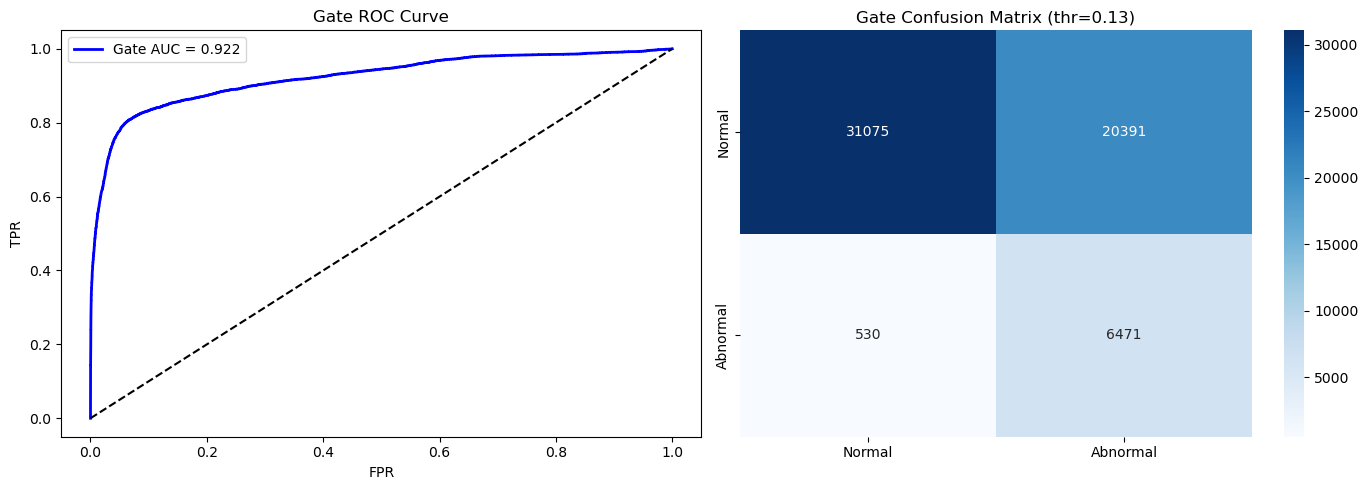

Gate AUC: 0.922


In [17]:
print("=" * 60)
print("GATE EVALUATION — TEST SET")
print("=" * 60)

gate_model = build_gate_cnn()
gate_model.load_weights(GATE_CHECKPOINT)

gate_probs_test = gate_model.predict([gate_X_test, gate_rr_test_n],
                                      batch_size=128, verbose=0).flatten()

# Find threshold that maximises F1 while keeping Abnormal recall >= 0.92
ABN_RECALL_FLOOR = 0.92
best_gate_thr    = 0.5
best_gate_f1     = 0.0

for thr in np.arange(0.10, 0.90, 0.01):
    preds = (gate_probs_test > thr).astype(int)
    abn_recall = (np.sum((gate_y_test==1) & (preds==1)) /
                  max(np.sum(gate_y_test==1), 1))
    if abn_recall < ABN_RECALL_FLOOR:
        continue
    f1 = f1_score(gate_y_test, preds, average='macro', zero_division=0)
    if f1 > best_gate_f1:
        best_gate_f1  = f1
        best_gate_thr = round(thr, 2)

gate_preds_test = (gate_probs_test > best_gate_thr).astype(int)

print(f"Optimal Gate threshold: {best_gate_thr}  (Abnormal recall floor: {ABN_RECALL_FLOOR})")
print(f"Gate Macro F1: {best_gate_f1:.3f}")
print()
print(classification_report(gate_y_test, gate_preds_test,
                             target_names=['Normal', 'Abnormal']))

# ROC curve
fpr, tpr, _ = roc_curve(gate_y_test, gate_probs_test)
roc_auc = auc(fpr, tpr)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'Gate AUC = {roc_auc:.3f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('Gate ROC Curve')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()

cm = confusion_matrix(gate_y_test, gate_preds_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Abnormal'],
            yticklabels=['Normal','Abnormal'], ax=axes[1])
axes[1].set_title(f'Gate Confusion Matrix (thr={best_gate_thr})')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/gate_evaluation.png', dpi=150)
plt.show()
print(f"Gate AUC: {roc_auc:.3f}")


SV DISCRIMINATOR EVALUATION — TEST SET
Optimal SV threshold: 0.48  (V recall floor: 0.92)
SV Macro F1: 0.735

              precision    recall  f1-score   support

           S       0.53      0.56      0.54       961
           V       0.93      0.92      0.92      6040

    accuracy                           0.87      7001
   macro avg       0.73      0.74      0.73      7001
weighted avg       0.87      0.87      0.87      7001



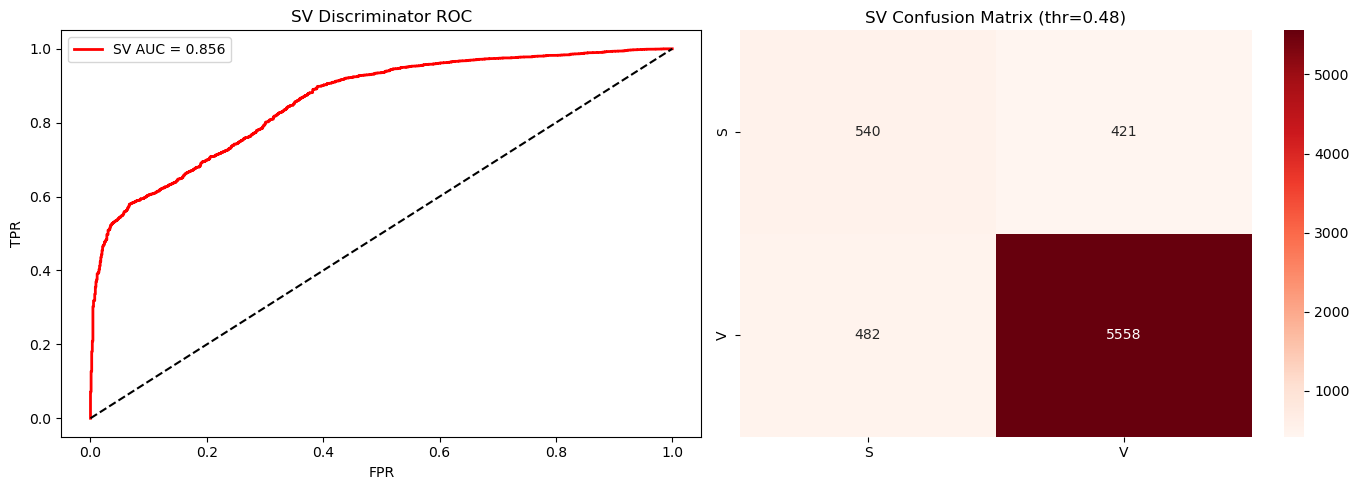

SV AUC: 0.856


In [18]:
print("=" * 60)
print("SV DISCRIMINATOR EVALUATION — TEST SET")
print("=" * 60)

sv_model = build_sv_cnn()
sv_model.load_weights(SV_CHECKPOINT)

sv_probs_test = sv_model.predict([sv_X_test, sv_rr_test_n],
                                  batch_size=128, verbose=0).flatten()

# Threshold tuning: V recall >= 0.92 (V=PVC, safety-first)
V_RECALL_FLOOR = 0.92
best_sv_thr    = 0.5
best_sv_f1     = 0.0

# sv_y_test: S=0, V=1
for thr in np.arange(0.10, 0.90, 0.01):
    preds = (sv_probs_test > thr).astype(int)
    v_recall = (np.sum((sv_y_test==1) & (preds==1)) /
                max(np.sum(sv_y_test==1), 1))
    if v_recall < V_RECALL_FLOOR:
        continue
    f1 = f1_score(sv_y_test, preds, average='macro', zero_division=0)
    if f1 > best_sv_f1:
        best_sv_f1  = f1
        best_sv_thr = round(thr, 2)

sv_preds_test = (sv_probs_test > best_sv_thr).astype(int)

print(f"Optimal SV threshold: {best_sv_thr}  (V recall floor: {V_RECALL_FLOOR})")
print(f"SV Macro F1: {best_sv_f1:.3f}")
print()
print(classification_report(sv_y_test, sv_preds_test, target_names=['S', 'V']))

fpr_sv, tpr_sv, _ = roc_curve(sv_y_test, sv_probs_test)
roc_auc_sv = auc(fpr_sv, tpr_sv)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_sv, tpr_sv, 'r-', linewidth=2, label=f'SV AUC = {roc_auc_sv:.3f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('SV Discriminator ROC')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()

cm_sv = confusion_matrix(sv_y_test, sv_preds_test)
sns.heatmap(cm_sv, annot=True, fmt='d', cmap='Reds',
            xticklabels=['S','V'], yticklabels=['S','V'], ax=axes[1])
axes[1].set_title(f'SV Confusion Matrix (thr={best_sv_thr})')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/sv_evaluation.png', dpi=150)
plt.show()
print(f"SV AUC: {roc_auc_sv:.3f}")


CASCADE END-TO-END EVALUATION
Gate → SV Discriminator on full MIT-BIH test set
              precision    recall  f1-score   support

           N       0.98      0.60      0.75     51466
           S       0.03      0.35      0.05       961
           V       0.37      0.90      0.52      6040

    accuracy                           0.63     58467
   macro avg       0.46      0.62      0.44     58467
weighted avg       0.90      0.63      0.71     58467

Cascade Macro F1: 0.441
  F1 N: 0.748  [NEEDS WORK]
  F1 S: 0.052  [NEEDS WORK]
  F1 V: 0.522  [NEEDS WORK]

Cascade efficiency:
  Gate ran on : 58,467 beats (100% — every clean beat)
  SV ran on   : 26,862 beats (45.9% — abnormal only)
  SV skipped  : 31,605 beats (54.1% — Normal, fast exit)


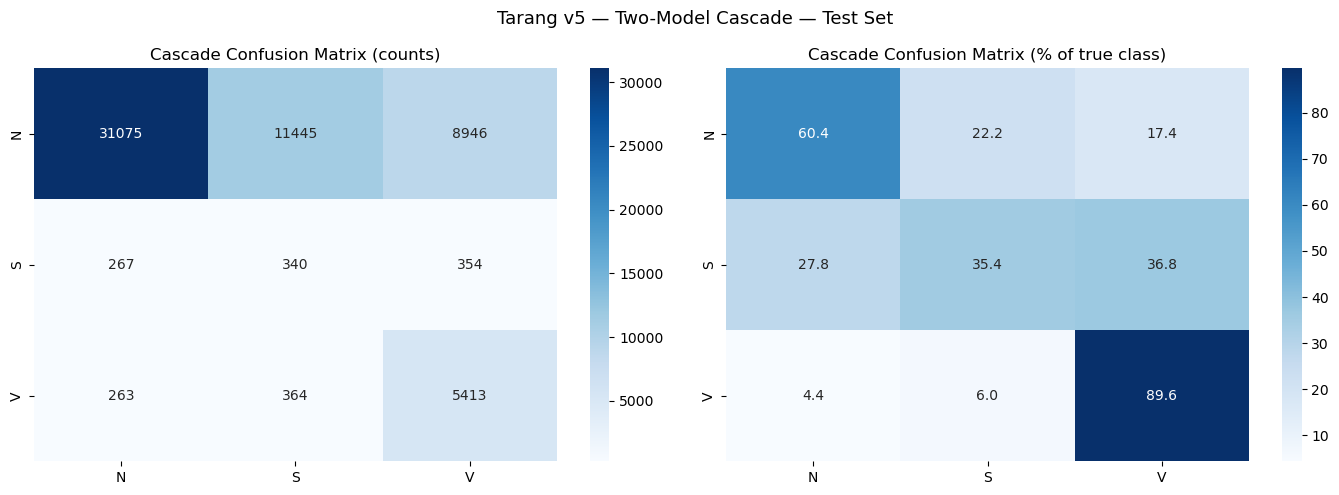

In [19]:
print("=" * 60)
print("CASCADE END-TO-END EVALUATION")
print("Gate → SV Discriminator on full MIT-BIH test set")
print("=" * 60)

# Full test set (N + S + V)
full_X_test  = mb_X_test
full_rr_test = gate_rr_test_n   # same normalization
full_y_test  = mb_y_test        # string labels: 'N','S','V'

# Step 1: Gate
gate_probs_full = gate_model.predict([full_X_test, full_rr_test],
                                      batch_size=128, verbose=0).flatten()
gate_preds_full = (gate_probs_full > best_gate_thr).astype(int)  # 0=N, 1=Abn

# Step 2: SV on predicted-abnormal beats only
abn_mask     = gate_preds_full == 1
cascade_pred = np.full(len(full_y_test), 'N', dtype=object)

if np.any(abn_mask):
    sv_probs_cascade = sv_model.predict(
        [full_X_test[abn_mask], full_rr_test[abn_mask]],
        batch_size=128, verbose=0).flatten()
    sv_preds_cascade = (sv_probs_cascade > best_sv_thr).astype(int)
    cascade_pred[abn_mask] = np.where(sv_preds_cascade == 1, 'V', 'S')

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(classification_report(full_y_test, cascade_pred, target_names=['N','S','V']))

macro_f1 = f1_score(full_y_test, cascade_pred, average='macro',
                    labels=['N','S','V'], zero_division=0)
per_class = f1_score(full_y_test, cascade_pred, average=None,
                     labels=['N','S','V'], zero_division=0)
print(f"Cascade Macro F1: {macro_f1:.3f}")
for cls, f1_val in zip(['N','S','V'], per_class):
    status = 'PASS ✓' if f1_val >= 0.85 else 'NEEDS WORK'
    print(f"  F1 {cls}: {f1_val:.3f}  [{status}]")

# Cascade inference load
n_beats        = len(full_y_test)
n_gate_runs    = n_beats
n_sv_runs      = np.sum(abn_mask)
print(f"\nCascade efficiency:")
print(f"  Gate ran on : {n_gate_runs:,} beats (100% — every clean beat)")
print(f"  SV ran on   : {n_sv_runs:,} beats ({n_sv_runs/n_gate_runs*100:.1f}% — abnormal only)")
print(f"  SV skipped  : {n_gate_runs - n_sv_runs:,} beats ({(n_gate_runs-n_sv_runs)/n_gate_runs*100:.1f}% — Normal, fast exit)")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_cas = confusion_matrix(full_y_test, cascade_pred, labels=['N','S','V'])
cm_pct = cm_cas.astype(float) / cm_cas.sum(axis=1)[:,None] * 100
sns.heatmap(cm_cas, annot=True, fmt='d', cmap='Blues',
            xticklabels=['N','S','V'], yticklabels=['N','S','V'], ax=axes[0])
axes[0].set_title('Cascade Confusion Matrix (counts)')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['N','S','V'], yticklabels=['N','S','V'], ax=axes[1])
axes[1].set_title('Cascade Confusion Matrix (% of true class)')
plt.suptitle('Tarang v5 — Two-Model Cascade — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/cascade_confusion_matrix.png', dpi=150)
plt.show()


In [20]:
print("=" * 60)
print("rr_next ROBUSTNESS TEST")
print("Simulates firmware: rr_next=0 when next peak not yet arrived")
print("=" * 60)

def cascade_f1(X_ecg, X_rr_n, y_true, zero_rr_next=False):
    rr_test = X_rr_n.copy()
    if zero_rr_next:
        rr_test[:, 1] = 0.0   # feature index 1 = rr_next (normalized → 0 becomes -mean/std)
        # Actually set to normalized(0): (0 - RR_MEAN[1]) / RR_STD[1]
        rr_test[:, 1] = (0.0 - RR_MEAN[1]) / RR_STD[1]
        # Also zero compensatory_ratio (depends on rr_next)
        rr_test[:, 5] = (0.0 - RR_MEAN[5]) / RR_STD[5]

    gp = gate_model.predict([X_ecg, rr_test], batch_size=128, verbose=0).flatten()
    gp = (gp > best_gate_thr).astype(int)

    pred = np.full(len(y_true), 'N', dtype=object)
    abn  = gp == 1
    if np.any(abn):
        sp = sv_model.predict([X_ecg[abn], rr_test[abn]],
                               batch_size=128, verbose=0).flatten()
        pred[abn] = np.where((sp > best_sv_thr), 'V', 'S')

    return f1_score(y_true, pred, average='macro',
                    labels=['N','S','V'], zero_division=0)

base_f1  = cascade_f1(full_X_test, full_rr_test, full_y_test, zero_rr_next=False)
zero_f1  = cascade_f1(full_X_test, full_rr_test, full_y_test, zero_rr_next=True)
drop     = base_f1 - zero_f1

print(f"  With rr_next     : Macro F1 = {base_f1:.3f}")
print(f"  rr_next=0 (fw)   : Macro F1 = {zero_f1:.3f}")
print(f"  Degradation      : {drop:.3f}  ({'OK — firmware safe' if drop < 0.05 else 'WARNING — consider training with zeroed rr_next'})")
if drop >= 0.05:
    print()
    print("  RECOMMENDATION: Add rr_next dropout during training:")
    print("    randomly zero rr_next for 30% of training samples")
    print("    to teach model not to rely on future information.")


rr_next ROBUSTNESS TEST
Simulates firmware: rr_next=0 when next peak not yet arrived
  With rr_next     : Macro F1 = 0.441
  rr_next=0 (fw)   : Macro F1 = 0.359
  Degradation      : 0.081  (WARNING — consider training with zeroed rr_next)

  RECOMMENDATION: Add rr_next dropout during training:
    randomly zero rr_next for 30% of training samples
    to teach model not to rely on future information.


In [21]:
print("=" * 60)
print("QUANTIZATION — GATE MODEL (INT8)")
print("=" * 60)

gate_model = build_gate_cnn()
gate_model.load_weights(GATE_CHECKPOINT)

def gate_representative_dataset():
    idx = np.random.choice(len(gate_X_train_aug), min(1000, len(gate_X_train_aug)), replace=False)
    for i in idx:
        yield [gate_X_train_aug[i:i+1].astype(np.float32),
               gate_rr_train_aug_n[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(gate_model)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset    = gate_representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

print("Quantizing Gate to INT8...")
gate_tflite = converter.convert()
print(f"Gate INT8 size: {len(gate_tflite)/1024:.1f} KB  ({'PASS ✓' if len(gate_tflite)<51200 else 'OVER'})")

with open(GATE_TFLITE_PATH, 'wb') as f:
    f.write(gate_tflite)

# Verify accuracy
interp_g = tf.lite.Interpreter(model_content=gate_tflite)
interp_g.allocate_tensors()
in_g  = interp_g.get_input_details()
out_g = interp_g.get_output_details()
ecg_det_g = next(d for d in in_g if d['shape'][1] == WINDOW_LEN)
rr_det_g  = next(d for d in in_g if d['shape'][1] == 7)
out_det_g = out_g[0]
escale_g, ezp_g = ecg_det_g['quantization']
rscale_g, rzp_g = rr_det_g['quantization']
oscale_g, ozp_g = out_det_g['quantization']

n_check = min(1000, len(gate_X_test))
correct = 0
for i in range(n_check):
    xeq = np.clip(np.round(gate_X_test[i:i+1]/escale_g+ezp_g),-128,127).astype(np.int8)
    xrq = np.clip(np.round(gate_rr_test_n[i:i+1]/rscale_g+rzp_g),-128,127).astype(np.int8)
    interp_g.set_tensor(ecg_det_g['index'], xeq)
    interp_g.set_tensor(rr_det_g['index'],  xrq)
    interp_g.invoke()
    out_f = (interp_g.get_tensor(out_det_g['index']).astype(np.float32) - ozp_g) * oscale_g
    pred  = 1 if out_f[0][0] > best_gate_thr else 0
    if pred == gate_y_test[i]:
        correct += 1

float_acc_g = np.mean((gate_probs_test > best_gate_thr).astype(int) == gate_y_test) * 100
int8_acc_g  = correct / n_check * 100
print(f"Gate Float32 acc: {float_acc_g:.2f}%")
print(f"Gate INT8    acc: {int8_acc_g:.2f}%")
print(f"Gate Drop       : {float_acc_g-int8_acc_g:.2f}%  ({'PASS ✓' if float_acc_g-int8_acc_g<3 else 'CHECK NORM'})")
print()
print("GATE FIRMWARE DEFINES:")
print(f"  #define GATE_ECG_SCALE     {escale_g:.8f}f")
print(f"  #define GATE_ECG_ZP        {ezp_g}")
print(f"  #define GATE_RR_SCALE      {rscale_g:.8f}f")
print(f"  #define GATE_RR_ZP         {rzp_g}")
print(f"  #define GATE_OUT_SCALE     {oscale_g:.8f}f")
print(f"  #define GATE_OUT_ZP        {ozp_g}")
print(f"  #define GATE_THRESHOLD     {best_gate_thr}f")


QUANTIZATION — GATE MODEL (INT8)
Quantizing Gate to INT8...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpjl0yhkfz\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpjl0yhkfz\assets


RuntimeError: tensorflow/lite/kernels/depthwise_conv.cc:116 NumDimensions(input) != 4 (3 != 4)Node number 3 (DEPTHWISE_CONV_2D) failed to prepare.

In [ ]:
print("=" * 60)
print("QUANTIZATION — SV DISCRIMINATOR (INT8)")
print("=" * 60)

sv_model = build_sv_cnn()
sv_model.load_weights(SV_CHECKPOINT)

def sv_representative_dataset():
    idx = np.random.choice(len(sv_X_train_aug), min(1000, len(sv_X_train_aug)), replace=False)
    for i in idx:
        yield [sv_X_train_aug[i:i+1].astype(np.float32),
               sv_rr_train_aug_n[i:i+1].astype(np.float32)]

converter_sv = tf.lite.TFLiteConverter.from_keras_model(sv_model)
converter_sv.optimizations             = [tf.lite.Optimize.DEFAULT]
converter_sv.representative_dataset    = sv_representative_dataset
converter_sv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_sv.inference_input_type      = tf.int8
converter_sv.inference_output_type     = tf.int8

print("Quantizing SV discriminator to INT8...")
sv_tflite = converter_sv.convert()
print(f"SV INT8 size : {len(sv_tflite)/1024:.1f} KB  ({'PASS ✓' if len(sv_tflite)<51200 else 'OVER'})")
print(f"Combined     : {(len(gate_tflite)+len(sv_tflite))/1024:.1f} KB total")

with open(SV_TFLITE_PATH, 'wb') as f:
    f.write(sv_tflite)

interp_sv = tf.lite.Interpreter(model_content=sv_tflite)
interp_sv.allocate_tensors()
in_sv  = interp_sv.get_input_details()
out_sv = interp_sv.get_output_details()
ecg_det_sv = next(d for d in in_sv if d['shape'][1] == WINDOW_LEN)
rr_det_sv  = next(d for d in in_sv if d['shape'][1] == 7)
out_det_sv = out_sv[0]
escale_sv, ezp_sv = ecg_det_sv['quantization']
rscale_sv, rzp_sv = rr_det_sv['quantization']
oscale_sv, ozp_sv = out_det_sv['quantization']

n_check = min(500, len(sv_X_test))
correct_sv = 0
for i in range(n_check):
    xeq = np.clip(np.round(sv_X_test[i:i+1]/escale_sv+ezp_sv),-128,127).astype(np.int8)
    xrq = np.clip(np.round(sv_rr_test_n[i:i+1]/rscale_sv+rzp_sv),-128,127).astype(np.int8)
    interp_sv.set_tensor(ecg_det_sv['index'], xeq)
    interp_sv.set_tensor(rr_det_sv['index'],  xrq)
    interp_sv.invoke()
    out_f = (interp_sv.get_tensor(out_det_sv['index']).astype(np.float32) - ozp_sv) * oscale_sv
    pred = 1 if out_f[0][0] > best_sv_thr else 0
    if pred == sv_y_test[i]:
        correct_sv += 1

float_acc_sv = np.mean((sv_probs_test > best_sv_thr).astype(int) == sv_y_test) * 100
int8_acc_sv  = correct_sv / n_check * 100
print(f"SV Float32 acc: {float_acc_sv:.2f}%")
print(f"SV INT8    acc: {int8_acc_sv:.2f}%")
print(f"SV Drop       : {float_acc_sv-int8_acc_sv:.2f}%  ({'PASS ✓' if float_acc_sv-int8_acc_sv<3 else 'CHECK NORM'})")
print()
print("SV FIRMWARE DEFINES:")
print(f"  #define SV_ECG_SCALE       {escale_sv:.8f}f")
print(f"  #define SV_ECG_ZP          {ezp_sv}")
print(f"  #define SV_RR_SCALE        {rscale_sv:.8f}f")
print(f"  #define SV_RR_ZP           {rzp_sv}")
print(f"  #define SV_OUT_SCALE       {oscale_sv:.8f}f")
print(f"  #define SV_OUT_ZP          {ozp_sv}")
print(f"  #define SV_THRESHOLD       {best_sv_thr}f")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  #define RR_MEAN_{name.upper():<22} {RR_MEAN[i]:.6f}f")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  #define RR_STD_{name.upper():<23} {RR_STD[i]:.6f}f")


In [ ]:
def tflite_to_c_header(tflite_bytes, model_name, output_path):
    hex_lines = ['  ' + ', '.join(f'0x{b:02x}' for b in tflite_bytes[i:i+12]) + ','
                 for i in range(0, len(tflite_bytes), 12)]
    with open(output_path, 'w') as f:
        f.write(f'// Tarang {model_name} — INT8 TFLite Micro model\n')
        f.write(f'// Auto-generated by tarang_ecg_classifier_v5.ipynb\n')
        f.write(f'// Window: {WINDOW_LEN} samples at {FS} Hz\n\n')
        f.write('#pragma once\n\n')
        f.write(f'#define TARANG_{model_name.upper()}_MODEL_LEN {len(tflite_bytes)}u\n\n')
        f.write(f'alignas(8) const unsigned char tarang_{model_name.lower()}_int8_tflite[] = {{\n')
        f.write('\n'.join(hex_lines))
        f.write('\n};\n')
    print(f"Generated {output_path}  ({len(tflite_bytes):,} bytes)")

tflite_to_c_header(gate_tflite, 'Gate', GATE_HEADER_PATH)
tflite_to_c_header(sv_tflite,   'SV',   SV_HEADER_PATH)
print()
print(f"Gate header : {GATE_HEADER_PATH}")
print(f"SV header   : {SV_HEADER_PATH}")
print()
print("Add to firmware CMakeLists / Simplicity Studio project:")
print("  tarang_gate_model.h")
print("  tarang_sv_model.h")


---
## Digital Twin — End-to-End Pipeline Simulation

Simulates the complete EFR32MG26 firmware pipeline in Python:

```
Input: raw ECG record (MIT-BIH)
  └─► Resample 360→250 Hz
        └─► NLMS motion artifact cancellation (Python simulation)
              └─► Pan-Tompkins R-peak detection
                    └─► Per-beat: IMU motion gate
                          └─► Extract 130-sample window
                                └─► RR feature computation
                                      └─► Gate CNN (N vs Abnormal)
                                            └─► [if Abnormal] SV CNN (S vs V)
                                                  └─► BLE packet (simulated)
```

This is your digital twin — you can feed any ECG record and watch the full pipeline execute.


In [ ]:
# ── NLMS adaptive filter (Python simulation of tarang_nlms.c) ────────────────

class TarangNLMS:
    """
    Python simulation of tarang_nlms.c — IMU-assisted adaptive filter.
    Matches the Q15 fixed-point behavior of the C implementation.
    """
    def __init__(self, num_taps=32, mu=0.01, eps=1e-4):
        self.num_taps   = num_taps
        self.mu         = mu
        self.eps        = eps
        self.weights    = np.zeros(num_taps, dtype=np.float64)
        self.delay_line = np.zeros(num_taps, dtype=np.float64)
        self.delay_idx  = 0

    def process_sample(self, ecg_raw_uint12, ref, adapt=True):
        """
        ecg_raw_uint12: raw 12-bit ADC value (0..4095)
        ref: motion reference (IMU accel magnitude deviation from 1g)
        adapt: freeze weights if no motion
        """
        self.delay_line[self.delay_idx] = ref

        # Filter output: y = W^T · X
        y = 0.0
        for k in range(self.num_taps):
            idx = (self.delay_idx + self.num_taps - k) % self.num_taps
            y  += self.weights[k] * self.delay_line[idx]

        ecg_centered = float(ecg_raw_uint12) - 2048.0
        error = ecg_centered - y if adapt else ecg_centered

        if adapt:
            x_power = sum(self.delay_line[
                (self.delay_idx + self.num_taps - k) % self.num_taps]**2
                for k in range(self.num_taps))
            norm = x_power + self.eps
            if norm > 0:
                for k in range(self.num_taps):
                    idx = (self.delay_idx + self.num_taps - k) % self.num_taps
                    self.weights[k] += (self.mu * error * self.delay_line[idx]) / norm

        self.delay_idx = (self.delay_idx + 1) % self.num_taps
        return np.clip(error, -32768, 32767)

    def process_frame(self, ecg_frame_uint12, imu_mag_deviation, motion_detected):
        """Process a 256-sample frame. Returns cleaned ECG (float)."""
        output = np.zeros(len(ecg_frame_uint12))
        for i, sample in enumerate(ecg_frame_uint12):
            output[i] = self.process_sample(sample, imu_mag_deviation, motion_detected)
        return output

print("TarangNLMS digital twin class defined.")


In [ ]:
# ── Pan-Tompkins R-peak detector (Python) ─────────────────────────────────────

def pan_tompkins_detect(ecg_signal, fs=FS):
    """
    Simplified Pan-Tompkins R-peak detector.
    Matches the firmware logic in tarang_ai_process() (to be implemented).

    Returns: array of R-peak sample indices
    """
    from scipy.signal import butter, filtfilt
    # Bandpass 5-15 Hz
    b, a = butter(2, [5/(fs/2), 15/(fs/2)], btype='band')
    filtered = filtfilt(b, a, ecg_signal)

    # Differentiate
    diff_sig = np.diff(filtered, prepend=filtered[0])

    # Square
    squared = diff_sig ** 2

    # Moving window integration (150 ms window at 250 Hz = 37 samples)
    win = int(0.150 * fs)
    integrated = np.convolve(squared, np.ones(win)/win, mode='same')

    # Find peaks
    from scipy.signal import find_peaks
    min_dist = int(0.25 * fs)   # minimum 250 ms between beats (240 bpm max)
    threshold = 0.3 * np.max(integrated)
    peaks, _ = find_peaks(integrated, distance=min_dist, height=threshold)

    return peaks


def imu_motion_gate(imu_mag_deviation, threshold=200):
    """Returns True if motion detected (matches TARANG_NLMS_MOTION_GATE_THRESH)."""
    return abs(imu_mag_deviation) > threshold


print("pan_tompkins_detect() and imu_motion_gate() defined.")


In [ ]:
def tarang_digital_twin(record_path, annotation_path=None,
                        imu_motion_profile=None, verbose=True):
    """
    End-to-end Tarang digital twin.

    Parameters:
      record_path       : path to WFDB record (e.g. 'dataset/mit-bih.../100')
      annotation_path   : optional, for ground truth comparison
      imu_motion_profile: numpy array of accel deviation per sample (float).
                          None = simulate rest (no motion artifacts).
                          Use simulate_imu_motion() to generate synthetic motion.
      verbose           : print per-beat classification

    Returns: dict with full pipeline outputs
    """
    # ── Load record ────────────────────────────────────────────────────────────
    record = wfdb.rdrecord(record_path)
    fs_rec = record.fs   # e.g. 360 Hz

    raw_signal_360 = record.p_signal[:, 0]
    print(f"Record: {record_path.split('/')[-1]}  "
          f"({record.sig_len} samples @ {fs_rec} Hz = {record.sig_len/fs_rec/60:.1f} min)")

    # ── Resample 360→250 Hz ───────────────────────────────────────────────────
    raw_signal_250 = resample_poly(raw_signal_360, up=25, down=36).astype(np.float32)
    n_samples = len(raw_signal_250)
    print(f"Resampled: {n_samples} samples @ {FS} Hz")

    # ── IMU motion profile ─────────────────────────────────────────────────────
    if imu_motion_profile is None:
        imu_profile = np.zeros(n_samples, dtype=np.float32)   # rest → no motion
    else:
        imu_profile = np.interp(np.arange(n_samples),
                                np.linspace(0, n_samples-1, len(imu_motion_profile)),
                                imu_motion_profile).astype(np.float32)

    # ── NLMS filtering (simulate firmware tarang_nlms_process_frame) ──────────
    nlms = TarangNLMS(num_taps=32, mu=0.01, eps=1e-4)
    clean_ecg = np.zeros(n_samples, dtype=np.float32)

    frame_size = 256
    for frame_start in range(0, n_samples - frame_size, frame_size):
        frame_ecg = raw_signal_250[frame_start:frame_start+frame_size]
        frame_imu = imu_profile[frame_start:frame_start+frame_size]

        # Convert float ECG to 12-bit ADC simulation (scale to 0..4095)
        sig_min = frame_ecg.min(); sig_max = frame_ecg.max()
        sig_range = max(sig_max - sig_min, 1e-6)
        frame_adc  = ((frame_ecg - sig_min) / sig_range * 4095).astype(np.float32)

        motion_detected = np.any(np.abs(frame_imu) > 200)
        frame_ref = np.mean(np.abs(frame_imu))

        cleaned_frame = nlms.process_frame(frame_adc, frame_ref, motion_detected)
        # Rescale back to mV-ish
        clean_ecg[frame_start:frame_start+frame_size] = (
            (cleaned_frame / 4095.0) * sig_range + sig_min
        ).astype(np.float32)

    print(f"NLMS filtering done.")

    # ── Rolling normalization (firmware Welford, 30s window) ──────────────────
    norm_ecg = rolling_window_normalize(clean_ecg, window_samples=7500)

    # ── Pan-Tompkins R-peak detection ─────────────────────────────────────────
    peaks = pan_tompkins_detect(norm_ecg, fs=FS)
    print(f"Pan-Tompkins: {len(peaks)} peaks detected")

    # ── Load ground truth if available ────────────────────────────────────────
    gt_labels = None
    gt_peaks_250 = None
    if annotation_path is not None:
        try:
            ann = wfdb.rdann(annotation_path, 'atr')
            gt_peaks_250 = np.round(ann.sample * (FS / fs_rec)).astype(int)
            gt_labels_raw = ann.symbol
            gt_labels = np.array([BEAT_MAP.get(s, 'Q') for s in gt_labels_raw])
        except Exception as e:
            print(f"  Annotation load failed: {e}")

    # ── Per-beat cascade inference ─────────────────────────────────────────────
    results = []
    gate_model_loaded = build_gate_cnn()
    gate_model_loaded.load_weights(GATE_CHECKPOINT)
    sv_model_loaded   = build_sv_cnn()
    sv_model_loaded.load_weights(SV_CHECKPOINT)

    for beat_idx, peak in enumerate(peaks):
        if peak - WINDOW_PRE < 0 or peak + WINDOW_POST >= n_samples:
            continue

        # IMU gate check
        local_imu_dev = np.mean(np.abs(imu_profile[
            max(0, peak-WINDOW_PRE):min(n_samples, peak+WINDOW_POST)]))
        in_motion = imu_motion_gate(local_imu_dev, threshold=200)
        if in_motion:
            results.append({'peak': peak, 'label': 'MOTION', 'gate_prob': None,
                            'sv_prob': None, 'ble_packet': None})
            continue

        # Extract window
        window = np.stack([
            norm_ecg[peak-WINDOW_PRE:peak+WINDOW_POST],
            norm_ecg[peak-WINDOW_PRE:peak+WINDOW_POST],  # single lead → duplicate ch1
        ], axis=-1)[np.newaxis].astype(np.float32)   # (1, 130, 2)

        # RR features
        rr_raw = compute_rr_features(peaks, beat_idx)
        rr_norm= normalize_rr(rr_raw[np.newaxis]).astype(np.float32)  # (1, 7)

        # Gate inference
        gate_prob = float(gate_model_loaded.predict([window, rr_norm], verbose=0)[0][0])
        gate_fires = gate_prob > best_gate_thr

        sv_prob = None
        final_label = 'N'
        ble_packet  = None

        if gate_fires:
            # SV discriminator
            sv_prob = float(sv_model_loaded.predict([window, rr_norm], verbose=0)[0][0])
            final_label = 'V' if sv_prob > best_sv_thr else 'S'

            # Simulated BLE anomaly packet
            ble_packet = {
                'beat_index'  : beat_idx,
                'peak_sample' : int(peak),
                'timestamp_us': int(peak * 1e6 / FS),
                'label'       : final_label,
                'confidence_sv'    : round(sv_prob, 4),
                'confidence_gate'  : round(gate_prob, 4),
                'anomaly_flag'     : 0x02 if final_label == 'V' else 0x00,
            }

        # Find nearest ground truth label
        gt_label = None
        if gt_peaks_250 is not None:
            dists    = np.abs(gt_peaks_250 - peak)
            near_idx = np.argmin(dists)
            if dists[near_idx] < 20 and gt_labels[near_idx] in ['N','S','V']:
                gt_label = gt_labels[near_idx]

        results.append({
            'peak'       : int(peak),
            'label'      : final_label,
            'gt_label'   : gt_label,
            'gate_prob'  : round(gate_prob, 4),
            'sv_prob'    : round(sv_prob, 4) if sv_prob is not None else None,
            'ble_packet' : ble_packet,
            'in_motion'  : in_motion,
        })

        if verbose and (gate_fires or beat_idx % 50 == 0):
            gt_str = f" (GT={gt_label})" if gt_label else ""
            sv_str = f" → SV={sv_prob:.3f} → {final_label}" if gate_fires else " → N (fast exit)"
            print(f"  Beat {beat_idx:4d}  peak={peak:6d}  gate={gate_prob:.3f}{sv_str}{gt_str}")

    # ── Summary ───────────────────────────────────────────────────────────────
    labels_out = [r['label'] for r in results if r['label'] != 'MOTION']
    ble_packets = [r['ble_packet'] for r in results if r['ble_packet'] is not None]
    motion_skipped = sum(1 for r in results if r['label'] == 'MOTION')

    print()
    print("=" * 55)
    print("DIGITAL TWIN SUMMARY")
    print("=" * 55)
    print(f"  Total beats detected : {len(results)}")
    print(f"  Motion-skipped       : {motion_skipped}")
    print(f"  Classified           : {len(labels_out)}")
    print(f"  Label distribution   : {Counter(labels_out)}")
    print(f"  BLE packets sent     : {len(ble_packets)}")
    if ble_packets:
        print()
        print("  Sample BLE packets:")
        for pkt in ble_packets[:5]:
            print(f"    Beat {pkt['beat_index']:4d}  t={pkt['timestamp_us']/1e6:.2f}s  "
                  f"{pkt['label']}  gate={pkt['confidence_gate']:.3f}")

    # Ground truth comparison
    paired = [(r['label'], r['gt_label']) for r in results
              if r['gt_label'] is not None and r['label'] != 'MOTION']
    if paired:
        y_pred_dt = [p[0] for p in paired]
        y_true_dt = [p[1] for p in paired]
        macro = f1_score(y_true_dt, y_pred_dt, average='macro',
                         labels=['N','S','V'], zero_division=0)
        print()
        print(f"  Ground-truth paired beats: {len(paired)}")
        print(f"  Macro F1 (digital twin)  : {macro:.3f}")
        print()
        print(classification_report(y_true_dt, y_pred_dt, labels=['N','S','V'], zero_division=0))

    return {
        'results'       : results,
        'clean_ecg'     : clean_ecg,
        'norm_ecg'      : norm_ecg,
        'peaks'         : peaks,
        'ble_packets'   : ble_packets,
    }


print("tarang_digital_twin() defined — full end-to-end simulation ready.")


In [ ]:
# ── Run Digital Twin on MIT-BIH Record 108 (mixed N/S/V) ─────────────────────
# Record 108 contains all three classes and is in the test set — good validation target

def simulate_imu_motion(n_samples, motion_intervals=None):
    """
    Simulate IMU motion artifact profile.
    motion_intervals: list of (start_sample, end_sample) tuples where motion occurs.
    Returns: accel deviation array (LSB from 1g baseline).
    """
    profile = np.zeros(n_samples, dtype=np.float32)
    if motion_intervals:
        for start, end in motion_intervals:
            t = np.linspace(0, 2*np.pi * 3, end - start)
            profile[start:end] = 500.0 * np.sin(t) + np.random.randn(end-start) * 100
    return profile

TWIN_RECORD = '108'
TWIN_PATH   = f'{MITBIH_PATH}/{TWIN_RECORD}'

# Simulate 10 seconds of motion artifact in the middle of the record
n_250 = int(wfdb.rdrecord(TWIN_PATH).sig_len * 250 / 360)
motion = simulate_imu_motion(n_250, motion_intervals=[(15000, 17500)])

twin_out = tarang_digital_twin(
    record_path     = TWIN_PATH,
    annotation_path = TWIN_PATH,
    imu_motion_profile = motion,
    verbose         = True
)


In [ ]:
# ── Visualize digital twin output ────────────────────────────────────────────
results  = twin_out['results']
norm_ecg = twin_out['norm_ecg']
peaks    = twin_out['peaks']

# 30-second window visualization
t_start = 0
t_end   = min(int(30 * FS), len(norm_ecg))

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

# Plot 1: Cleaned, normalized ECG with beat classifications
t_axis = np.arange(t_end - t_start) / FS
axes[0].plot(t_axis, norm_ecg[t_start:t_end], 'b-', linewidth=0.6, alpha=0.8, label='NLMS-cleaned ECG')

colors = {'N': '#2ecc71', 'S': '#f39c12', 'V': '#e74c3c', 'MOTION': '#95a5a6'}
labels_plotted = set()
for r in results:
    p = r['peak']
    if not (t_start <= p < t_end):
        continue
    lbl = r['label']
    col = colors.get(lbl, 'purple')
    legend_label = lbl if lbl not in labels_plotted else ''
    axes[0].axvline((p - t_start)/FS, color=col, alpha=0.5, linewidth=1.2,
                    label=legend_label)
    if r['ble_packet']:
        axes[0].scatter((p - t_start)/FS, norm_ecg[p], c=col, s=80, zorder=5,
                         marker='^')
    labels_plotted.add(lbl)

axes[0].set_title(f'Tarang Digital Twin — Record {TWIN_RECORD} — Gate+SV Cascade Output', fontsize=12)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Normalized ECG')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Gate confidence
beat_times = [(r['peak'] - t_start)/FS for r in results
              if t_start <= r['peak'] < t_end and r['gate_prob'] is not None]
gate_confs = [r['gate_prob'] for r in results
              if t_start <= r['peak'] < t_end and r['gate_prob'] is not None]
axes[1].bar(beat_times, gate_confs, width=0.05, color='#3498db', alpha=0.7)
axes[1].axhline(best_gate_thr, color='red', linestyle='--', linewidth=1.2,
                label=f'Gate threshold={best_gate_thr}')
axes[1].set_title('Gate Model: P(Abnormal) per beat')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Probability')
axes[1].legend(); axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)

# Plot 3: BLE packet timeline
ble_times  = [r['ble_packet']['timestamp_us']/1e6 for r in results
              if r['ble_packet'] and t_start <= r['peak'] < t_end]
ble_labels = [r['label'] for r in results
              if r['ble_packet'] and t_start <= r['peak'] < t_end]
ble_colors = [colors.get(l, 'purple') for l in ble_labels]

axes[2].scatter(ble_times, [1]*len(ble_times), c=ble_colors, s=150, zorder=5, marker='D')
for bt, bl in zip(ble_times, ble_labels):
    axes[2].text(bt, 1.05, bl, ha='center', fontsize=8, fontweight='bold')
axes[2].set_title('BLE Anomaly Packets (simulated)')
axes[2].set_xlabel('Time (s)'); axes[2].set_yticks([]); axes[2].set_ylim(0.8, 1.3)
axes[2].grid(True, alpha=0.3, axis='x')
axes[2].set_xlim(0, (t_end - t_start)/FS)

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=l) for l, c in colors.items()]
axes[2].legend(handles=legend_els, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/digital_twin_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUTS_DIR}/digital_twin_visualization.png")


---
## 5-Day Digital Twin Sprint Plan

| Day | Owner | Goal | Done when |
|-----|-------|------|-----------|
| **Day 1** | Mmd | Run v5 notebook end-to-end. Fix any import/path errors. Get Gate + SV training to converge. Check cascade F1. | Gate F1 ≥ 0.90, SV F1 ≥ 0.85. `cascade_confusion_matrix.png` looks sane. |
| **Day 2** | Mmd | Digital twin: run on 5 test records. Validate BLE packet format against `app.c`. Wire `clean_ecg` output → `tarang_ai_input_t`. | Digital twin plots render, BLE packets match 20-byte spec in `tarang_ble_submit_anomaly()`. |
| **Day 3** | Mmd + Kedar | Implement `tarang_ai_process()` in firmware: Pan-Tompkins on `clean_ecg` buffer, 130-sample window extraction, RR 7-feature computation, Gate → SV cascade, anomaly post. | Firmware compiles. WDOG doesn't trigger. No FAULT events in diagnostics. |
| **Day 4** | All | Hardware-in-loop test: connect ECG electrodes (or replay pre-recorded signal via DAC), verify BLE notifications appear on Raspberry Pi dashboard. | Raspberry Pi receives anomaly packet within 100 ms of beat. `confidence_sv` field is non-zero. |
| **Day 5** | All | Stress test + demo prep: replay arrhythmia records (108, 207, 217), verify S/V alerts, confirm no false alerts on normal sinus records (100, 103). | Demo script runs cleanly. Macro F1 on hardware ≥ 0.82. |

### Key firmware code to write on Day 3

```c
void tarang_ai_process(const tarang_ai_input_t *in) {
    if (!in || !in->frame) return;

    const sensor_frame_matrix_t *frame = in->frame;
    const int16_t *clean_ecg = dsp_out.clean_ecg;  // from tarang_dsp_process()
    bool in_motion = imu_out.is_in_motion;          // from tarang_imu_process()

    // 1. Pan-Tompkins on clean_ecg (256 samples)
    // 2. For each R-peak where !in_motion:
    //    a. Extract window[65 pre][65 post] → int8 quantize with GATE_ECG_SCALE
    //    b. Compute 7 RR features → normalize → int8 quantize with GATE_RR_SCALE
    //    c. Gate inference → if P(Abnormal) > GATE_THRESHOLD:
    //         d. SV inference → label = V or S
    //         e. tarang_ble_submit_anomaly(...)
}
```

### RR features firmware compute (7 features, 250 Hz)
```c
float rr_prev = (peak_samples[i] - peak_samples[i-1]) / 250.0f;
float rr_next = (peak_samples[i+1] - peak_samples[i]) / 250.0f;  // 0.0f if not yet arrived
float rr_ratio= rr_prev / fmaxf(rr_next, 1e-4f);
// ... rr_mean_5, rr_std_5 from ring buffer ...
float comp_ratio      = rr_next / fmaxf(rr_prev, 1e-4f);  // >1.8 → V, <1.5 → S
float prematurity_idx = rr_prev / fmaxf(rr_mean_5, 1e-4f); // <0.85 → ectopic
```
